In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (train_test_split,GridSearchCV)
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import (
accuracy_score,
confusion_matrix,
classification_report,
precision_score,
recall_score,
f1_score
)

In [14]:
data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target
print("Dataset Shape:", X.shape)
print("Target Shape :", y.shape)

Dataset Shape: (569, 30)
Target Shape : (569,)


<BarContainer object of 2 artists>

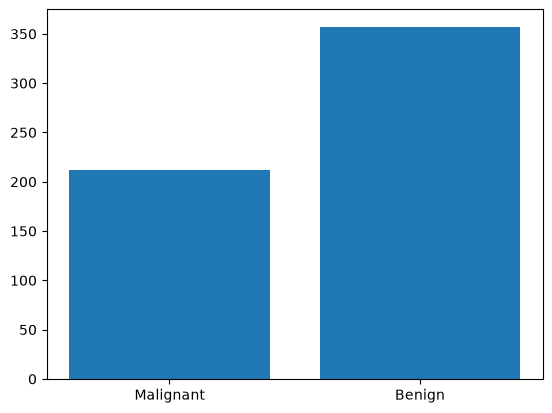

In [17]:
plt.bar(['Malignant', 'Benign'],
    y.value_counts().sort_index())

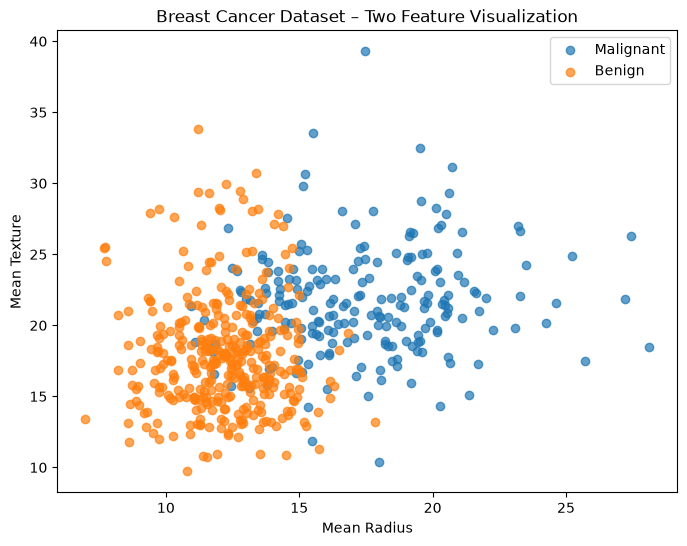

In [18]:
plt.figure(figsize=(8,6))

for target_value, label in [(0, 'Malignant'), (1, 'Benign')]:
    subset = X[y == target_value]

    plt.scatter(
        subset['mean radius'],
        subset['mean texture'],
        label=label,
        alpha=0.7
    )

plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.title("Breast Cancer Dataset – Two Feature Visualization")
plt.legend()
plt.show()


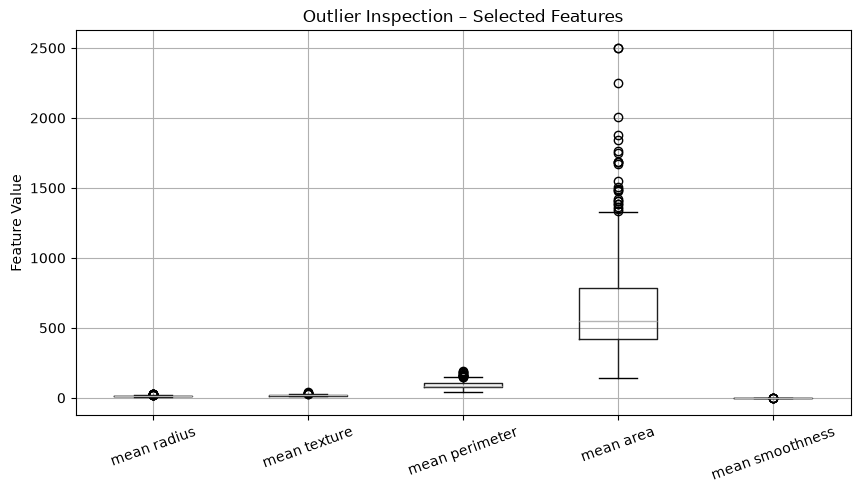

In [19]:
features_to_plot = [
    'mean radius',
    'mean texture',
    'mean perimeter',
    'mean area',
    'mean smoothness'
]

plt.figure(figsize=(10,5))
X[features_to_plot].boxplot()
plt.xticks(rotation=20)
plt.title("Outlier Inspection – Selected Features")
plt.ylabel("Feature Value")
plt.show()

In [20]:
X = data.data
y = data.target

print("Number of features:", X.shape[1])
print("Number of observations:", X.shape[0])

Number of features: 30
Number of observations: 569


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (455, 30)
Testing data : (114, 30)


In [22]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [23]:
svm_linear=SVC(
    kernel="linear",
    C=1
)
svm_linear.fit(X_train,y_train)
print("Linear SVM trained successfully.")

Linear SVM trained successfully.


In [24]:
svm_poly=SVC(
    kernel="poly",
    degree=4,
    C=1,
    gamma='scale'
)
svm_poly.fit(X_train_scaled, y_train)

print("Polynomial SVM trained successfully.")

Polynomial SVM trained successfully.


In [25]:
svm_rbf=SVC(
    kernel='rbf',
    C=1,
    gamma="scale"
)
svm_rbf.fit(X_train_scaled, y_train)

print("RBF SVM trained successfully.")

RBF SVM trained successfully.


In [27]:
print("Number of support vectors – Linear SVM:",
    len(svm_linear.support_) )
print("Number of support vectors – Polynomial SVM:",
      len(svm_poly.support_))

print("Number of support vectors – RBF SVM:",
      len(svm_rbf.support_))

Number of support vectors – Linear SVM: 49
Number of support vectors – Polynomial SVM: 240
Number of support vectors – RBF SVM: 97


In [28]:
X_vis=X[["mean radius","mean texture"]]
X_vis_train, X_vis_test, y_vis_train, y_vis_test = train_test_split(
    X_vis,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

vis_scaler = StandardScaler()

X_vis_train_scaled = vis_scaler.fit_transform(X_vis_train)
X_vis_test_scaled = vis_scaler.transform(X_vis_test)

In [29]:
vis_linear = SVC(kernel='linear', C=1)
vis_poly = SVC(kernel='poly', degree=3, C=1, gamma='scale')
vis_rbf = SVC(kernel='rbf', C=1, gamma='scale')

vis_linear.fit(X_vis_train_scaled, y_vis_train)
vis_poly.fit(X_vis_train_scaled, y_vis_train)
vis_rbf.fit(X_vis_train_scaled, y_vis_train)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [30]:
def plot_decision_boundary(model, X, y, title):
    X_array = np.asarray(X)
    y_array = np.asarray(y)

    x_min, x_max = X_array[:, 0].min() - 1, X_array[:, 0].max() + 1
    y_min, y_max = X_array[:, 1].min() - 1, X_array[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(7,5))

    plt.contourf(
        xx, yy, Z,
        alpha=0.20
    )

    plt.scatter(
        X_array[:, 0],
        X_array[:, 1],
        c=y_array,
        edgecolors='k',
        s=45
    )

    # Highlight support vectors
    if hasattr(model, 'support_vectors_'):
        sv = model.support_vectors_

        plt.scatter(
            sv[:, 0],
            sv[:, 1],
            facecolors='none',
            edgecolors='black',
            s=120,
            linewidths=1.5,
            label='Support Vectors'
        )

        plt.legend()

    plt.xlabel("Standardized Mean Radius")
    plt.ylabel("Standardized Mean Texture")
    plt.title(title)
    plt.show()

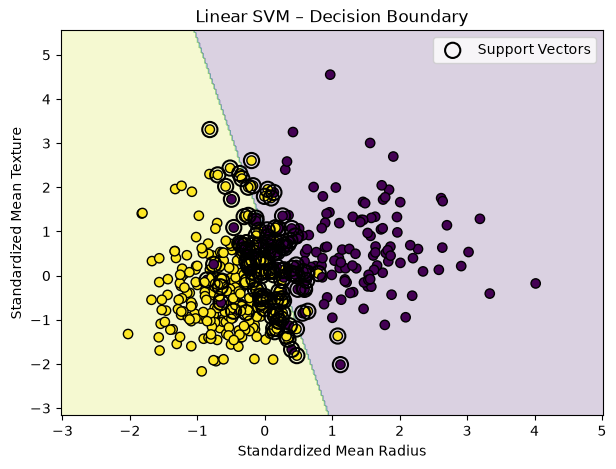

In [31]:
plot_decision_boundary(
    vis_linear,
    X_vis_train_scaled,
    y_vis_train,
    "Linear SVM – Decision Boundary")

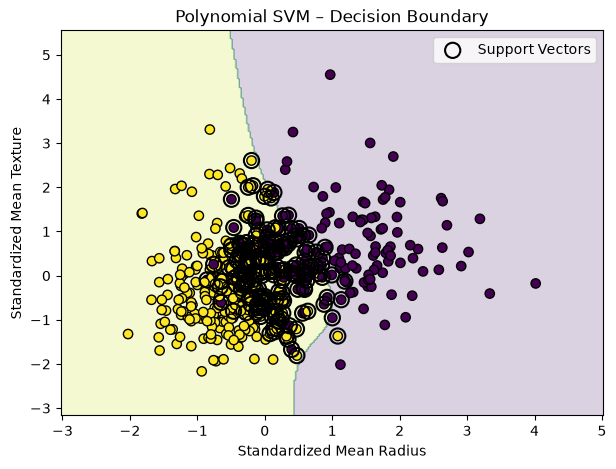

In [32]:
plot_decision_boundary(
    vis_poly,
    X_vis_train_scaled,
    y_vis_train,
    "Polynomial SVM – Decision Boundary"
)


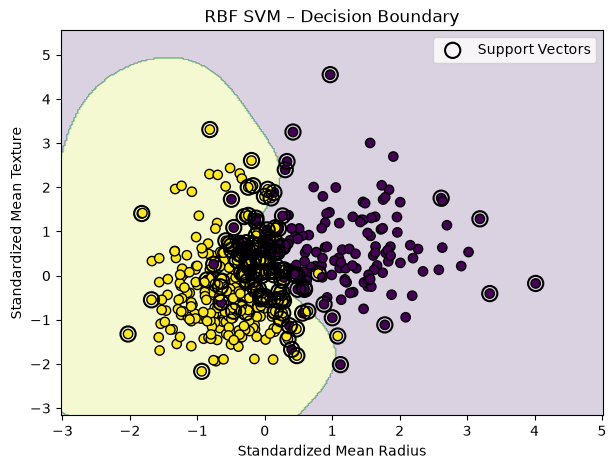

In [33]:
plot_decision_boundary(
    vis_rbf,
    X_vis_train_scaled,
    y_vis_train,
    "RBF SVM – Decision Boundary"
)

In [34]:
y_pred_linear = svm_linear.predict(X_test_scaled)
y_pred_poly = svm_poly.predict(X_test_scaled)
y_pred_rbf = svm_rbf.predict(X_test_scaled)

print("Predictions generated successfully.")


Predictions generated successfully.


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [35]:
def evaluate_model(name, y_true, y_pred):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred)
    }

results = pd.DataFrame([
    evaluate_model("Linear SVM", y_test, y_pred_linear),
    evaluate_model("Polynomial SVM", y_test, y_pred_poly),
    evaluate_model("RBF SVM", y_test, y_pred_rbf)
])

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Linear SVM,0.657895,0.648649,1.000000,0.786885
1,Polynomial SVM,0.780702,0.747368,0.986111,0.850299
2,RBF SVM,0.982456,0.986111,0.986111,0.986111


In [44]:
svm_pipeline=Pipeline([
    ('scaler',StandardScaler()),
    ('svm',SVC())
])
param_grid={
    'svm__kernel':['linear','poly',"rbf"],
    'svm__C':[0.1,1,10,100],
    'svm__degree':[2,3,4],
    'svm__gamma':['scale','auto',0.01,0.1,1]
}
grid_search=GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Score:")
print(grid_search.best_score_)

Best Parameters:
{'svm__C': 10, 'svm__degree': 2, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}

Best Cross-Validation Score:
0.9802197802197803


In [38]:
from sklearn.pipeline import Pipeline